# Capítulo 14 — Fundamentos de Tempestades: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | CAPE e CIN numa sondagem tropical | MetPy |
| 2 | do CAPE à corrente ascendente: $w_{max} = \sqrt{2\,\mathrm{CAPE}}$ | NumPy |
| 3 | hodógrafo e cisalhamento: que tempestade vai dar? | MetPy |
| 4 | a piscina fria e a frente de rajada (corrente de densidade) | `solve_ivp` |

Exercícios numéricos N1–N4 no fim; soluções em `cap14_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import metpy.calc as mpcalc
from metpy.units import units
from metpy.plots import SkewT, Hodograph
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

g = 9.8

## Caso 1 — CAPE e CIN: a energia guardada na sondagem

Sondagem idealizada de tarde de verão pré-tempestade: camada de mistura quente e úmida, **inversão-tampa** (CIN) e ar condicionalmente instável acima (Cap. 5). O CAPE é a área positiva entre a parcela e o ambiente no Skew-T:
$$\mathrm{CAPE} = \int_{LFC}^{EL} g\,\frac{T_{v,p} - T_{v,e}}{T_{v,e}}\,dz.$$

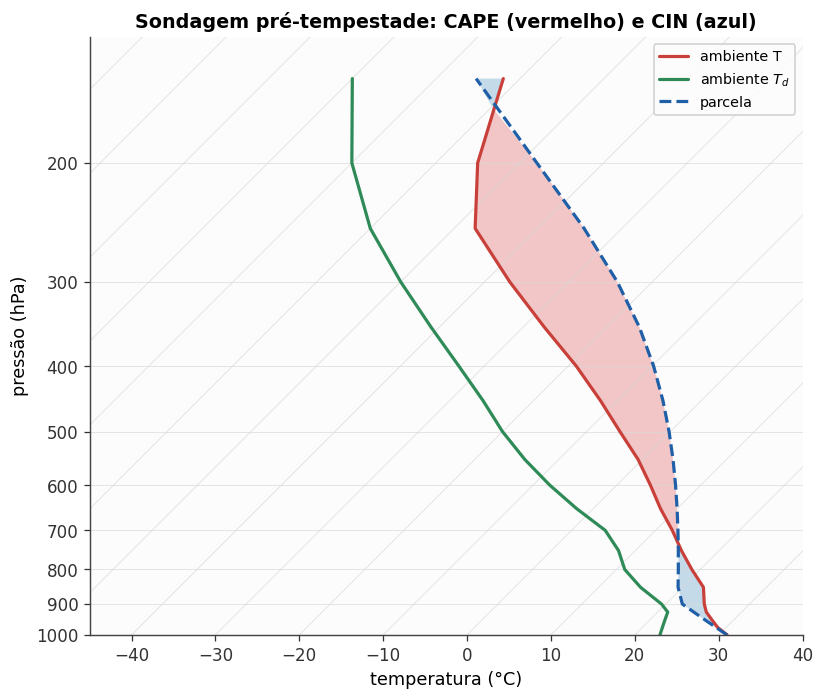

CAPE = 3477 J/kg | CIN = -94 J/kg
LCL = 890 hPa | LFC = 732 hPa | EL = 164 hPa
CAPE > 1500 J/kg com CIN moderado: atmosfera ARMADA esperando gatilho.


In [2]:
p = np.array([1000, 975, 950, 925, 900, 850, 800, 750, 700, 650, 600, 550,
              500, 450, 400, 350, 300, 250, 200, 150])*units.hPa
T = np.array([31, 29, 27.4, 25.8, 24.6, 22.5, 19, 15.5, 12, 8, 4, -0.5,
              -6, -12, -19, -27.5, -37, -47.5, -55, -62])*units.degC
Td = np.array([23, 22.4, 21.8, 21.2, 19.5, 15, 11, 8, 4, -2, -8, -14,
               -20, -26, -33, -41, -50, -60, -70, -80])*units.degC

prof = mpcalc.parcel_profile(p, T[0], Td[0]).to('degC')
cape, cin = mpcalc.cape_cin(p, T, Td, prof)
lcl_p, lcl_T = mpcalc.lcl(p[0], T[0], Td[0])
lfc_p, _ = mpcalc.lfc(p, T, Td, prof)
el_p, _ = mpcalc.el(p, T, Td, prof)

fig = plt.figure(figsize=(8, 8))
skew = SkewT(fig, rotation=45)
skew.plot(p, T, color=CORES['vermelho'], lw=2, label='ambiente T')
skew.plot(p, Td, color=CORES['verde'], lw=2, label='ambiente $T_d$')
skew.plot(p, prof, color=CORES['azul'], lw=2, ls='--', label='parcela')
skew.shade_cape(p, T, prof, alpha=0.25)
skew.shade_cin(p, T, prof, alpha=0.25)
skew.ax.set_xlabel('temperatura (°C)'); skew.ax.set_ylabel('pressão (hPa)')
skew.ax.set_ylim(1000, 130); skew.ax.set_xlim(-45, 40)
skew.ax.legend(loc='upper right', fontsize=9)
skew.ax.set_title('Sondagem pré-tempestade: CAPE (vermelho) e CIN (azul)')
plt.show()
print(f'CAPE = {cape.m:.0f} J/kg | CIN = {cin.m:.0f} J/kg')
print(f'LCL = {lcl_p.m:.0f} hPa | LFC = {lfc_p.m:.0f} hPa | EL = {el_p.m:.0f} hPa')
print('CAPE > 1500 J/kg com CIN moderado: atmosfera ARMADA esperando gatilho.')

## Caso 2 — Do CAPE ao updraft

Convertendo toda a energia em movimento: $\tfrac12 w^2 = \mathrm{CAPE}$, logo
$$w_{max} = \sqrt{2\,\mathrm{CAPE}}.$$
Na prática observa-se $w \approx w_{max}/2$: entranhamento, peso da água e perturbação de pressão cobram pedágio (Stull, §14.5).

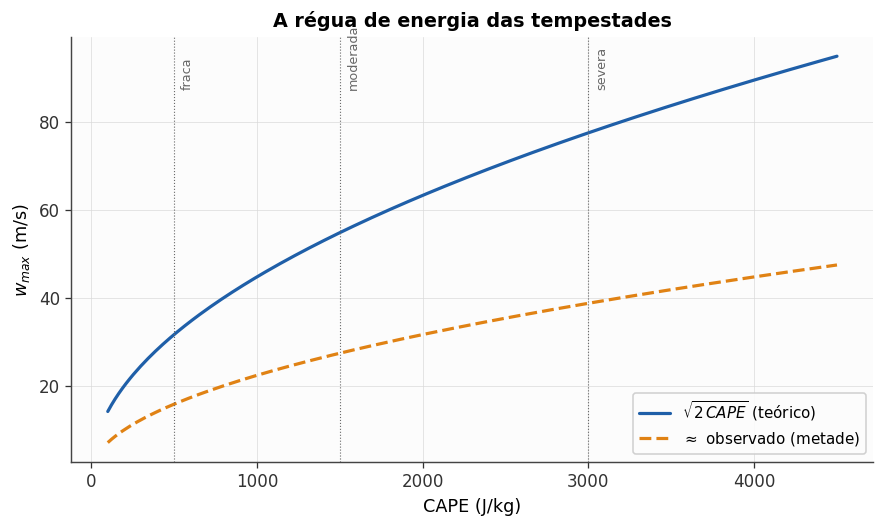

CAPE =  500 J/kg: w_teo = 31.6 m/s, realista ~ 15.8 m/s
CAPE = 1500 J/kg: w_teo = 54.8 m/s, realista ~ 27.4 m/s
CAPE = 3000 J/kg: w_teo = 77.5 m/s, realista ~ 38.7 m/s
updrafts de 25+ m/s sustentam granizo grande (Cap. 15).


In [3]:
CAPEs = np.linspace(100, 4500, 200)
w_teo = np.sqrt(2*CAPEs)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(CAPEs, w_teo, color=CORES['azul'], lw=2, label='$\\sqrt{2\\,CAPE}$ (teórico)')
ax.plot(CAPEs, w_teo/2, '--', color=CORES['laranja'], lw=2,
        label='$\\approx$ observado (metade)')
for cape_v, nome in [(500, 'fraca'), (1500, 'moderada'), (3000, 'severa')]:
    ax.axvline(cape_v, color=CORES['cinza'], lw=0.7, ls=':')
    ax.text(cape_v + 40, 88, nome, fontsize=8, color='#666666', rotation=90)
ax.set(xlabel='CAPE (J/kg)', ylabel='$w_{max}$ (m/s)',
       title='A régua de energia das tempestades')
ax.legend()
plt.show()
for c in [500, 1500, 3000]:
    print(f'CAPE = {c:4d} J/kg: w_teo = {np.sqrt(2*c):4.1f} m/s, '
          f'realista ~ {np.sqrt(2*c)/2:4.1f} m/s')
print('updrafts de 25+ m/s sustentam granizo grande (Cap. 15).')

## Caso 3 — O hodógrafo decide o tipo de tempestade

Mesmo CAPE, destinos diferentes: o **cisalhamento 0–6 km** organiza a tempestade.
- fraco (< 10 m/s): célula única (pulso, ~30 min);
- moderado (10–20 m/s): multicélula (linha, trem de células);
- forte (> 20 m/s), hodógrafo curvo: **supercélula** rotativa.

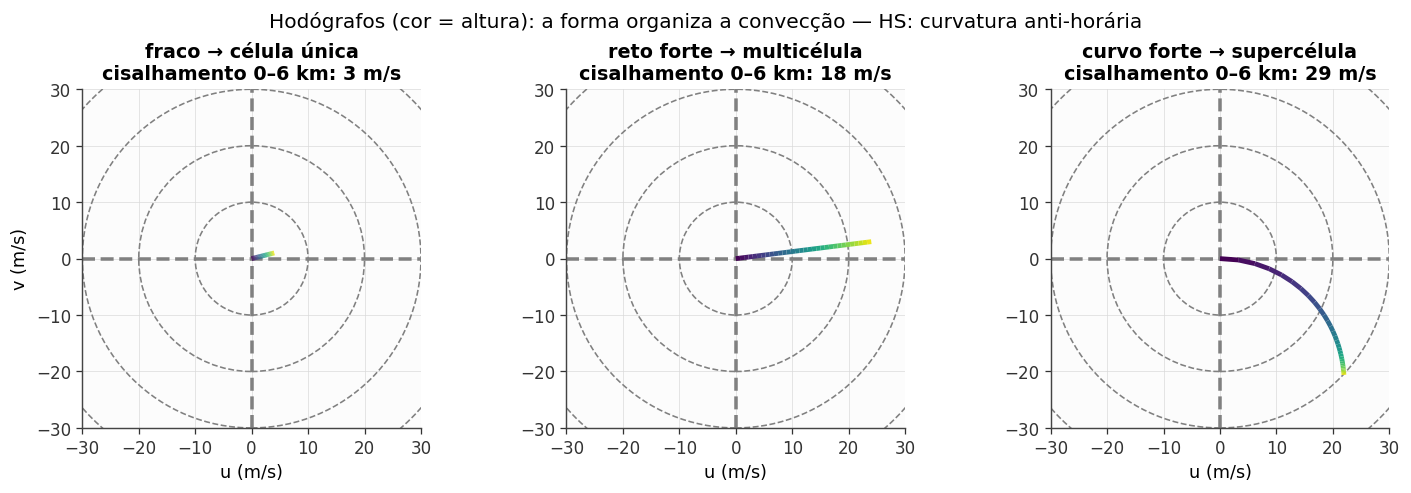

supercelula: o updraft inclinado separa-se da chuva (nao se afoga) e o
cisalhamento curvo gera rotacao — mesociclone (Cap. 15).


In [4]:
z = np.linspace(0, 8000, 33)

# três perfis de vento (m/s): fraco, reto forte, curvo forte (HS: giro anti-horário c/ altura)
u1 = 4*z/8000;                     v1 = 1*z/8000
u2 = 24*z/8000;                    v2 = 3*z/8000
ang = np.pi/2*(1 - np.exp(-z/2500))
u3 = 22*np.sin(ang);               v3 = -22*(1 - np.cos(ang))

fig, axs = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (u, v), nome in zip(axs, [(u1, v1), (u2, v2), (u3, v3)],
                             ['fraco → célula única', 'reto forte → multicélula',
                              'curvo forte → supercélula']):
    h = Hodograph(ax, component_range=30)
    h.add_grid(increment=10)
    h.plot_colormapped(u*units('m/s'), v*units('m/s'), z*units.m, cmap='viridis')
    shear = np.hypot(u[z <= 6000][-1] - u[0], v[z <= 6000][-1] - v[0])
    ax.set_title(f'{nome}\ncisalhamento 0–6 km: {shear:.0f} m/s')
    ax.set_xlabel('u (m/s)')
axs[0].set_ylabel('v (m/s)')
fig.suptitle('Hodógrafos (cor = altura): a forma organiza a convecção — HS: curvatura anti-horária')
fig.tight_layout()
plt.show()
print('supercelula: o updraft inclinado separa-se da chuva (nao se afoga) e o')
print('cisalhamento curvo gera rotacao — mesociclone (Cap. 15).')

## Caso 4 — A piscina fria e a frente de rajada

Chuva evaporando no ar seco sub-nuvem fabrica ar frio que desaba e se espalha como **corrente de densidade**:
$$c \simeq k\sqrt{g\,H\,\frac{\Delta\theta_v}{\theta_v}},\qquad k \approx \sqrt{2}.$$
A frente de rajada é o gatilho da próxima célula — a tempestade se auto-propaga.

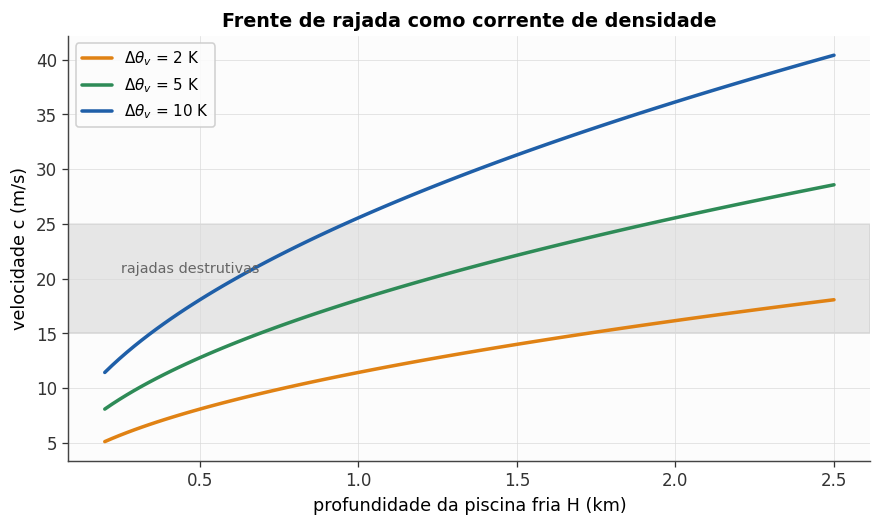

downdraft de 3 km com deficit de 4 K: chega ao chao a 10.2 m/s em 9 min —
espalha-se como piscina fria e ergue o ar vizinho: proxima celula.


In [5]:
theta0 = 300.0
H = np.linspace(200, 2500, 100)
fig, ax = plt.subplots(figsize=(9, 4.8))
for dth, cor in [(2, CORES['laranja']), (5, CORES['verde']), (10, CORES['azul'])]:
    c = np.sqrt(2*g*H*dth/theta0)
    ax.plot(H/1e3, c, color=cor, label=f'$\\Delta\\theta_v$ = {dth} K')
ax.axhspan(15, 25, color=CORES['cinza'], alpha=0.15)
ax.text(0.25, 20.5, 'rajadas destrutivas', fontsize=9, color='#666666')
ax.set(xlabel='profundidade da piscina fria H (km)', ylabel='velocidade c (m/s)',
       title='Frente de rajada como corrente de densidade')
ax.legend()
plt.show()

# mini-simulação: parcela do downdraft esfriada por evaporação
def down(t, y):
    z, w = y
    B = -g*4.0/theta0*np.exp(-max(z, 0)/2000)   # 4 K mais fria, decaindo
    return [w, B - 0.001*abs(w)*w]
s = solve_ivp(down, [0, 1200], [3000.0, 0.0], dense_output=True, rtol=1e-8,
              events=lambda t, y: y[0])
tt = np.linspace(0, s.t_events[0][0] if s.t_events[0].size else 1200, 200)
print(f'downdraft de 3 km com deficit de 4 K: chega ao chao a '
      f'{abs(s.sol(tt)[1][-1]):.1f} m/s em {tt[-1]/60:.0f} min —')
print('espalha-se como piscina fria e ergue o ar vizinho: proxima celula.')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap14_solucoes.ipynb`**.

**N1** — Na sondagem do Caso 1, aqueça a superfície de +1 em +1 K (até +4 K, com $T_d$ fixo) e trace CAPE e CIN contra o aquecimento; em que ponto a tampa 'estoura' (CIN → 0)?

**N2** — Integre a subida do updraft com entranhamento: $dw/dz = (B - \mu w^2)/w$ com $\mu = 0{,}5/H_{ent}$; varra $H_{ent}$ de 2 a 20 km e compare $w_{max}$ com $\sqrt{2CAPE}$.

**N3** — Calcule a helicidade relativa à tempestade (SRH 0–3 km) para os três hodógrafos do Caso 3 (movimento da tempestade: 75% do vento médio, 30° à esquerda no HS) e associe ao risco de supercélula.

**N4** — Equilíbrio RKW: compare a velocidade da piscina fria $c(\Delta\theta_v, H)$ com o cisalhamento de baixos níveis $\Delta u$ (0–2,5 km); trace o mapa $c/\Delta u$ e marque a faixa ótima ($\approx$ 1) para linhas de instabilidade duradouras.

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*